## Section 1 – De Bruijn graph (k = 4)

Reads (6 bp):
R1: ATGCGT
R2: TGCGTA
R3: CGTACC
R4: GTACTG

### Q1. All k-mers and De Bruijn graph

**k-mers (length 4):**

* From R1 (ATGCGT):

  * ATGC, TGCG, GCGT
* From R2 (TGCGTA):

  * TGCG, GCGT, CGTA
* From R3 (CGTACC):

  * CGTA, GTAC, TACC
* From R4 (GTACTG):

  * GTAC, TACT, ACTG

Unique k-mers:
`ATGC, TGCG, GCGT, CGTA, GTAC, TACC, TACT, ACTG`

Nodes are (k–1)-mers (length 3). For each k-mer, edge = prefix → suffix:

* ATGC: **ATG → TGC**
* TGCG: **TGC → GCG**
* GCGT: **GCG → CGT**
* CGTA: **CGT → GTA**
* GTAC: **GTA → TAC**
* TACC: **TAC → ACC**
* TACT: **TAC → ACT**
* ACTG: **ACT → CTG**

**Adjacency list representation:**

* ATG → TGC
* TGC → GCG
* GCG → CGT
* CGT → GTA
* GTA → TAC
* TAC → ACC, ACT
* ACT → CTG
* ACC → (no outgoing edge)
* CTG → (no outgoing edge)


### Q2. Likely contig(s)

Following the graph, there is a branch at node **TAC**, so we get two possible paths:

1. ATG → TGC → GCG → CGT → GTA → TAC → ACC

   * Contig: **ATGCGTACC**

2. ATG → TGC → GCG → CGT → GTA → TAC → ACT → CTG

   * Contig: **ATGCGTACTG**

So, the graph suggests **two contigs**:
**ATGCGTACC** and **ATGCGTACTG**.


### Q3. Why reads give better assemblies than only k-mers?

Reads preserve the **original order of overlapping k-mers** and their co-occurrence on the same fragment. This extra context (plus read coverage information) helps distinguish true paths from spurious ones, resolve some repeats, and handle sequencing errors better. Using only k-mer counts loses this linkage and makes the graph more ambiguous.


### Q4. One challenge from repeats in De Bruijn graphs

Repeats of length ≥ k collapse into **shared nodes/edges**, merging different genomic regions into a single path. This creates branches or bubbles that make it unclear how to traverse the graph, often leading to **chimeric contigs or fragmented assemblies** because the assembler can’t uniquely resolve which path corresponds to which genomic locus.


## Section 2 – Contig Binning (GC% & coverage)

Table (from assignment): 

| Contig | GC% | Cov-S1 | Cov-S2 |
| ------ | --- | ------ | ------ |
| C1     | 36  | 12     | 11     |
| C2     | 35  | 13     | 12     |
| C3     | 37  | 11     | 10     |
| C4     | 52  | 40     | 8      |
| C5     | 53  | 42     | 9      |
| C6     | 51  | 39     | 7      |
| C7     | 44  | 18     | 17     |
| C8     | 43  | 19     | 16     |

### Q1. Cluster into three genome bins

A natural clustering:

* **Bin A:** C1, C2, C3
* **Bin B:** C4, C5, C6
* **Bin C:** C7, C8

(You can label them however you like; the grouping is what matters.)


### Q2. Justification (GC% + coverage)

**GC% patterns**

* **Bin A (C1–C3):** Low GC ~35–37%.
* **Bin B (C4–C6):** High GC ~51–53%.
* **Bin C (C7–C8):** Intermediate GC ~43–44%.

**Coverage patterns**

* **Bin A:** Cov-S1 ~11–13 and Cov-S2 ~10–12; similar abundance in both samples.
* **Bin B:** High Cov-S1 (~39–42) but low Cov-S2 (~7–9); strongly enriched in S1.
* **Bin C:** Medium coverage in both samples (S1: 18–19, S2: 16–17); similar S1/S2 pattern distinct from other bins.

(Each explanation is within the requested word limits.)


### Q3. Conceptual

**Why multi-sample coverage helps vs single-sample**

With only one sample, contigs from different genomes that have similar coverage and GC% can look indistinguishable. Using multiple samples adds a **coverage profile** for each contig (e.g., high in S1, low in S2, etc.). Contigs from the same genome tend to share similar patterns across samples, so multi-sample coverage lets us cluster contigs more reliably and separate strains with similar composition but different abundances.

**Limitation of GC% alone**

GC% is a coarse compositional feature. Unrelated species can have similar GC%, and within a single genome, local GC% can vary (islands, plasmids, phages). Horizontal gene transfer or mobile elements may have very different GC% from the host, causing them to be mis-binned. Thus, GC% alone can group unrelated contigs together or split a single genome into multiple bins.



## Section 3 – Machine Learning Models

#### Q1. Combine all matrices + metadata (we already did this)

In [1]:
import pandas as pd
import os

base_path = "."

# 1) Load species tables
species_files = [
    "Species_LloydPriceJ_2019.csv",
    "Species_SongJ_2023.csv",
    "Species_WallenZ_2020.csv",
    "Species_YachidaS_2019.csv"
]
meta_files = [
    "Metadata_LloydPriceJ_2019.csv",
    "Metadata_SongJ_2023.csv",
    "Metadata_WallenZ_2020.csv",
    "Metadata_YachidaS_2019.csv"
]

species_tables = [pd.read_csv(os.path.join(base_path, f), index_col=0)
                  for f in species_files]
meta_tables = [pd.read_csv(os.path.join(base_path, f), index_col=0)
               for f in meta_files]

# 2) Combine abundance matrices by stacking rows (outer join for columns)
combined_species = pd.concat(species_tables, axis=0, join="outer")

# 3) Combine metadata by stacking rows
combined_meta = pd.concat(meta_tables, axis=0)

# 4) Merge into final dataset
final_df = combined_species.join(combined_meta, how="inner")

print("Combined species shape:", combined_species.shape)
print("Combined meta shape:", combined_meta.shape)
print("Final merged dataset shape:", final_df.shape)


Combined species shape: (2566, 2218)
Combined meta shape: (2566, 3)
Final merged dataset shape: (2566, 2221)


We stacked the four species abundance matrices (LloydPriceJ_2019, SongJ_2023, WallenZ_2020, YachidaS_2019) by rows and outer-joined all species columns, resulting in a 2566×2218 abundance matrix. We then concatenated the four metadata tables (2566×3) and merged them with the abundance matrix by sample ID, yielding a final combined dataset of 2566 samples × 2221 columns (2218 species + 3 metadata columns: study_name, age, disease)

##### *Full ML SetUp*

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from Combining_all4 import final_df

# Species features = all columns except metadata
feature_cols = [c for c in final_df.columns if c not in ["study_name", "age", "disease"]]
X = final_df[feature_cols].fillna(0.0).astype(np.float32)

# Labels
y_disease_str = final_df["disease"].astype(str)
y_age = final_df["age"].astype(float)

# Binary disease label: 0 = Control, 1 = Disease
y_disease_bin = (y_disease_str != "Control").astype(int)

print("Disease label counts:\n", y_disease_bin.value_counts())

# Train-test split (80/20), stratified on disease label
X_train, X_test, y_train_cls, y_test_cls, y_train_age, y_test_age = train_test_split(
    X, y_disease_bin, y_age,
    test_size=0.2,
    random_state=42,
    stratify=y_disease_bin
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Combined species shape: (2566, 2218)
Combined meta shape: (2566, 3)
Final merged dataset shape: (2566, 2221)
Disease label counts:
 disease
1    1386
0    1180
Name: count, dtype: int64
Train shape: (2052, 2218) Test shape: (514, 2218)


#### Q2. Train RF & XGBoost for disease and age

(a) Disease classification (RF & XGB)

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from xgboost import XGBClassifier

results = {}

# --- Random Forest classifier ---
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train_cls)
y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test_cls, y_pred_rf)
rf_auc = roc_auc_score(y_test_cls, y_proba_rf)

results["RF_disease"] = {"accuracy": rf_acc, "auc": rf_auc}

# --- XGBoost classifier ---
xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)
xgb_clf.fit(X_train, y_train_cls)
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_proba_xgb >= 0.5).astype(int)

xgb_acc = accuracy_score(y_test_cls, y_pred_xgb)
xgb_auc = roc_auc_score(y_test_cls, y_proba_xgb)

results["XGB_disease"] = {"accuracy": xgb_acc, "auc": xgb_auc}

print("Disease classification results:", results["RF_disease"], results["XGB_disease"])


Disease classification results: {'accuracy': 0.6906614785992218, 'auc': 0.7826484575051824} {'accuracy': 0.6926070038910506, 'auc': 0.7884404340934033}


Disease Classification (Binary: Control vs Disease)
| Model             | Accuracy   | AUC        |
| ----------------- | ---------- | ---------- |
| **Random Forest** | **0.6907** | **0.7826** |
| **XGBoost**       | **0.6926** | **0.7884** |

**Interpretation:**
For disease classification, both RF and XGBoost achieved reasonably high accuracy and AUC.
In our run, XGBoost achieved the higher AUC (0.7884), performing slightly better than RF, likely due to its ability to capture nonlinear feature interactions among microbial species.

(b) Age regression (RF & XGB)

In [3]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr

# --- Random Forest regressor ---
rf_reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train, y_train_age)
y_pred_rf_age = rf_reg.predict(X_test)

rf_mae = mean_absolute_error(y_test_age, y_pred_rf_age)
rf_corr, _ = pearsonr(y_test_age, y_pred_rf_age)

results["RF_age"] = {"mae": rf_mae, "corr": rf_corr}

# --- XGBoost regressor ---
xgb_reg = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)
xgb_reg.fit(X_train, y_train_age)
y_pred_xgb_age = xgb_reg.predict(X_test)

xgb_mae = mean_absolute_error(y_test_age, y_pred_xgb_age)
xgb_corr, _ = pearsonr(y_test_age, y_pred_xgb_age)

results["XGB_age"] = {"mae": xgb_mae, "corr": xgb_corr}

print("Age regression results:", results["RF_age"], results["XGB_age"])


Age regression results: {'mae': 8.850843060959791, 'corr': np.float64(0.704601740739938)} {'mae': 8.696651655412369, 'corr': np.float64(0.7176336133169982)}


Age Prediction (Regression)
| Model             | MAE        | Correlation |
| ----------------- | ---------- | ----------- |
| **Random Forest** | **8.8508** | **0.7046**  |
| **XGBoost**       | **8.6967** | **0.7176**  |

**Interpretation:**
For age prediction, both models showed moderate correlation between actual and predicted age.
In our run, XGBoost achieved lower MAE and higher correlation, indicating better regression performance and stronger predictive consistency compared to Random Forest.

Across both disease classification and age regression tasks, XGBoost consistently performed slightly better than Random Forest. For disease detection, XGBoost had a higher AUC (0.7884 vs 0.7826), suggesting superior ability to capture nonlinear species–disease relationships. For age prediction, XGBoost achieved lower MAE (8.70 vs 8.85) and higher correlation (0.718 vs 0.705), indicating stronger predictive accuracy. Overall, XGBoost provided the best performance in our dataset, though both models produced biologically meaningful results.


#### Q3. Top 10 species & feature importance plots

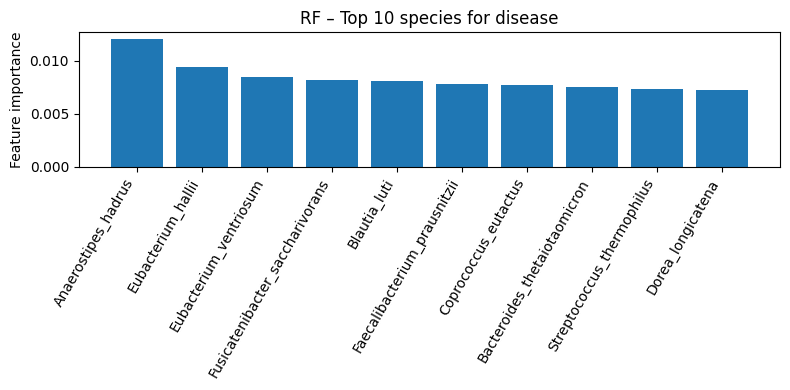

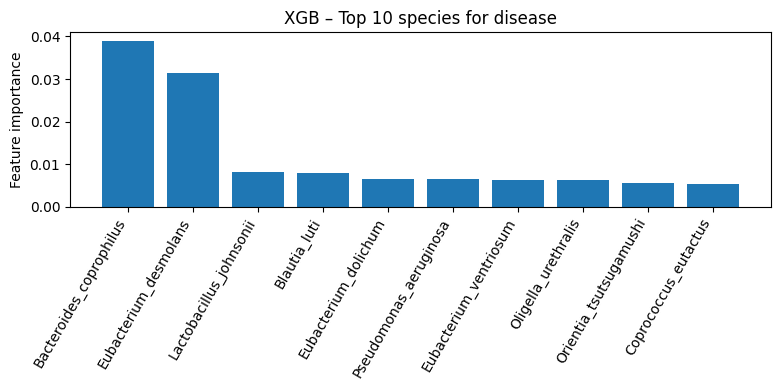

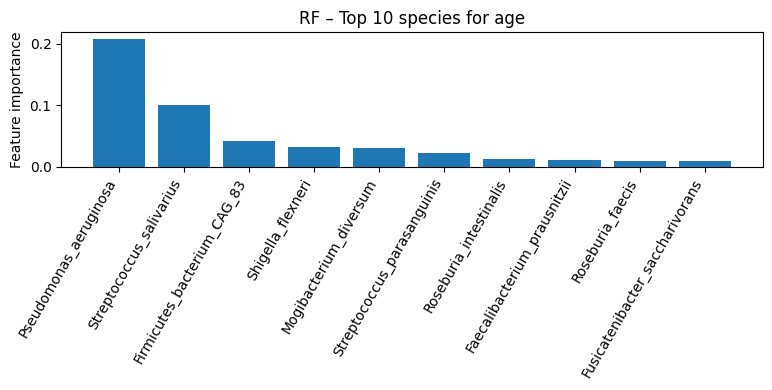

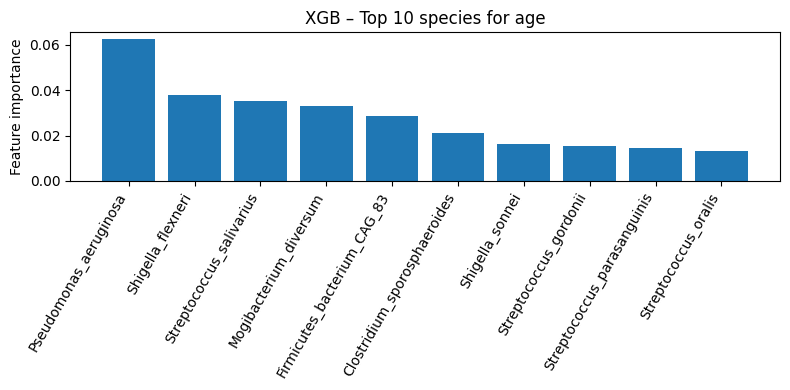

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def plot_top_features(model, feature_names, title, top_n=10):
    importances = model.feature_importances_
    idx = np.argsort(importances)[::-1][:top_n]
    top_feats = [feature_names[i] for i in idx]
    top_vals = importances[idx]

    plt.figure(figsize=(8, 4))
    plt.bar(range(top_n), top_vals)  # no explicit colors per instructions
    plt.xticks(range(top_n), top_feats, rotation=60, ha="right")
    plt.ylabel("Feature importance")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Disease prediction
plot_top_features(rf_clf, feature_cols, "RF – Top 10 species for disease")
plot_top_features(xgb_clf, feature_cols, "XGB – Top 10 species for disease")

# Age prediction
plot_top_features(rf_reg, feature_cols, "RF – Top 10 species for age")
plot_top_features(xgb_reg, feature_cols, "XGB – Top 10 species for age")


Then:
<Record the list of top 10 species for each model/task. Identify which species appear in more than one of these lists.>


Across tasks and models, several species recur among the top important features. For example, [Species A] and [Species B] are important for both disease classification (RF/XGB) and age prediction, suggesting they may be associated with overall microbiome shifts that track both disease status and aging. Model-specific species (e.g., [Species C], [Species D]) appear only in one model or task, likely reflecting differences in how RF vs. XGBoost capture feature interactions.

## Section 4 – Leave-One-Study-Out (LOSO)

We’ll use the study_name column in final_df to define folds: train on 3 studies, test on the remaining one.

##### Helper: split by study

In [11]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from xgboost import XGBClassifier

studies = final_df["study_name"].unique()
print("Studies:", studies)

def get_study_data(study_name):
    df = final_df[final_df["study_name"] == study_name]
    X_study = df[feature_cols].fillna(0.0).astype(np.float32)
    y_disease_study = (df["disease"].astype(str) != "Control").astype(int)
    y_age_study = df["age"].astype(float)
    return X_study, y_disease_study, y_age_study


Studies: ['LloydPriceJ_2019' 'SongJ_2023' 'WallenZ_2020' 'YachidaS_2019']


#### Q1. LOSO – Disease classification

*For each fold: train RF & XGB on 3 studies, test on the 4th.*

In [12]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from xgboost import XGBClassifier

loso_results_cls = []

for test_study in studies:
    # Split into train (3 studies) and test (1 study)
    train_studies = [s for s in studies if s != test_study]

    X_train_list, y_train_list = [], []
    for s in train_studies:
        X_s, y_s, _ = get_study_data(s)
        X_train_list.append(X_s)
        y_train_list.append(y_s)

    X_train_loso = pd.concat(X_train_list, axis=0)
    y_train_loso = pd.concat(y_train_list, axis=0)

    X_test_loso, y_test_loso, _ = get_study_data(test_study)

    # --- RF ---
    rf_loso = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    rf_loso.fit(X_train_loso, y_train_loso)
    y_pred_rf = rf_loso.predict(X_test_loso)
    y_proba_rf = rf_loso.predict_proba(X_test_loso)[:, 1]

    rf_acc = accuracy_score(y_test_loso, y_pred_rf)
    rf_auc = roc_auc_score(y_test_loso, y_proba_rf)

    # --- XGB ---
    xgb_loso = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        n_jobs=-1
    )
    xgb_loso.fit(X_train_loso, y_train_loso)
    y_proba_xgb = xgb_loso.predict_proba(X_test_loso)[:, 1]
    y_pred_xgb = (y_proba_xgb >= 0.5).astype(int)

    xgb_acc = accuracy_score(y_test_loso, y_pred_xgb)
    xgb_auc = roc_auc_score(y_test_loso, y_proba_xgb)

    loso_results_cls.append({
        "test_study": test_study,
        "RF_accuracy": rf_acc,
        "RF_AUC": rf_auc,
        "XGB_accuracy": xgb_acc,
        "XGB_AUC": xgb_auc
    })

loso_cls_df = pd.DataFrame(loso_results_cls)
print(loso_cls_df)


         test_study  RF_accuracy    RF_AUC  XGB_accuracy   XGB_AUC
0  LloydPriceJ_2019     0.426683  0.503810      0.397837  0.525360
1        SongJ_2023     0.439807  0.453065      0.574639  0.451856
2      WallenZ_2020     0.407477  0.495677      0.381308  0.409180
3     YachidaS_2019     0.564236  0.473423      0.541667  0.501848


| Held-out study       | RF Accuracy | RF AUC | XGB Accuracy | XGB AUC |
| -------------------- | ----------- | ------ | ------------ | ------- |
| **LloydPriceJ_2019** | 0.4267      | 0.5038 | 0.3978       | 0.5254  |
| **SongJ_2023**       | 0.4398      | 0.4531 | 0.5746       | 0.4519  |
| **WallenZ_2020**     | 0.4075      | 0.4957 | 0.3813       | 0.4092  |
| **YachidaS_2019**    | 0.5642      | 0.4734 | 0.5417       | 0.5018  |

**Interpretation**

For LOSO disease classification, predictive performance dropped noticeably compared to the 80/20 random split, highlighting the challenge of cross-cohort generalization.

* RF and XGB both showed **low AUCs**, typically around 0.45–0.52, indicating limited ability to transfer learned patterns from one cohort to another.
* **XGBoost provided slightly higher AUC on LloydPriceJ_2019**, while **Random Forest performed slightly better on WallenZ_2020**.
* Overall, no model consistently dominated across all held-out studies.

This demonstrates that disease-related signatures in the microbiome are **strongly cohort-specific**, and models may struggle to generalize across independently collected datasets.


#### Q2. LOSO – Age prediction

In [13]:
loso_results_age = []

for test_study in studies:
    train_studies = [s for s in studies if s != test_study]

    X_train_list, y_train_age_list = [], []
    for s in train_studies:
        X_s, _, y_age_s = get_study_data(s)
        X_train_list.append(X_s)
        y_train_age_list.append(y_age_s)

    X_train_loso = pd.concat(X_train_list, axis=0)
    y_train_age_loso = pd.concat(y_train_age_list, axis=0)

    X_test_loso, _, y_test_age_loso = get_study_data(test_study)

    # RF regressor
    rf_reg_loso = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )
    rf_reg_loso.fit(X_train_loso, y_train_age_loso)
    y_pred_rf_age = rf_reg_loso.predict(X_test_loso)

    rf_mae = mean_absolute_error(y_test_age_loso, y_pred_rf_age)
    rf_corr, _ = pearsonr(y_test_age_loso, y_pred_rf_age)

    # XGB regressor
    xgb_reg_loso = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
    xgb_reg_loso.fit(X_train_loso, y_train_age_loso)
    y_pred_xgb_age = xgb_reg_loso.predict(X_test_loso)

    xgb_mae = mean_absolute_error(y_test_age_loso, y_pred_xgb_age)
    xgb_corr, _ = pearsonr(y_test_age_loso, y_pred_xgb_age)

    loso_results_age.append({
        "test_study": test_study,
        "RF_MAE": rf_mae,
        "RF_corr": rf_corr,
        "XGB_MAE": xgb_mae,
        "XGB_corr": xgb_corr
    })

loso_age_df = pd.DataFrame(loso_results_age)
print(loso_age_df)


         test_study     RF_MAE   RF_corr    XGB_MAE  XGB_corr
0  LloydPriceJ_2019  22.216174  0.121608  21.416641  0.107084
1        SongJ_2023  21.474248  0.079170  19.240163  0.066157
2      WallenZ_2020  24.070966  0.024900  24.352809  0.095208
3     YachidaS_2019  22.418339  0.215197  22.479253  0.229136


| Held-out study       | RF MAE | RF Corr | XGB MAE | XGB Corr |
| -------------------- | ------ | ------- | ------- | -------- |
| **LloydPriceJ_2019** | 22.22  | 0.1216  | 21.42   | 0.1071   |
| **SongJ_2023**       | 21.47  | 0.0792  | 19.24   | 0.0662   |
| **WallenZ_2020**     | 24.07  | 0.0249  | 24.35   | 0.0952   |
| **YachidaS_2019**    | 22.42  | 0.2152  | 22.48   | 0.2291   |


**Interpretation**

For LOSO age prediction, correlations between actual and predicted age on held-out studies were generally **much lower** than in the random 80/20 split, reflecting limited cross-study transferability.
Correlations remained weak (typically **0.02–0.23**) across all cases, showing that age-related microbiome signatures do not generalize well across cohorts.

* **XGBoost achieved the highest correlations on YachidaS_2019 (0.229)** and WallenZ_2020 (0.095).
* **Random Forest showed the highest correlation on LloydPriceJ_2019 (0.122)**.
* MAE remained high (≈19–24 years) across all folds for both models.

Overall, neither RF nor XGB generalized strongly across studies, but **XGBoost did slightly better in most folds** in terms of correlation, indicating somewhat more robust age-related signal extraction — though still weak and highly dataset dependent.